Name: Premanshu Devendra Kusre

USN: CS23117

Subject: Machine Learning

Topic: Network Anomaly Detection

Dataset: UNSW-NB15

Model Used: Decision Tree Classifier

AIM

To implement the Decision Tree algorithm on the UNSW-NB15 dataset
for detecting network anomalies and classify network traffic as
normal or attack.

DATASET DESCRIPTION

The UNSW-NB15 dataset is a network intrusion detection dataset
created by the Australian Centre for Cyber Security.

It contains modern network traffic with both normal activities
and malicious attacks.

The dataset includes various network flow features such as
protocol, service, source bytes, destination bytes, packets,
TTL values, etc.

The target variable is 'label':
0 → Normal traffic
1 → Attack / anomaly

In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Load dataset

df = pd.read_csv("/content/drive/MyDrive/ML Dataset/UNSW_NB15_training-set.csv")



In [5]:
# Display first 5 rows
df.head()

,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.000011,udp,-,INT,2,0,496,0,90909.0902,...,1,2,0,0,0,1,2,0,Normal,0
1,2,0.000008,udp,-,INT,2,0,1762,0,125000.0003,...,1,2,0,0,0,1,2,0,Normal,0
2,3,0.000005,udp,-,INT,2,0,1068,0,200000.0051,...,1,3,0,0,0,1,3,0,Normal,0
3,4,0.000006,udp,-,INT,2,0,900,0,166666.6608,...,1,3,0,0,0,2,3,0,Normal,0
4,5,0.000010,udp,-,INT,2,0,2126,0,100000.0025,...,1,3,0,0,0,2,3,0,Normal,0


In [6]:
# Check dataset shape

df.shape


(82332, 45)

In [7]:
# Display dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82332 entries, 0 to 82331
Data columns (total 45 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 82332 non-null  int64  
 1   dur                82332 non-null  float64
 2   proto              82332 non-null  object 
 3   service            82332 non-null  object 
 4   state              82332 non-null  object 
 5   spkts              82332 non-null  int64  
 6   dpkts              82332 non-null  int64  
 7   sbytes             82332 non-null  int64  
 8   dbytes             82332 non-null  int64  
 9   rate               82332 non-null  float64
 10  sttl               82332 non-null  int64  
 11  dttl               82332 non-null  int64  
 12  sload              82332 non-null  float64
 13  dload              82332 non-null  float64
 14  sloss              82332 non-null  int64  
 15  dloss              82332 non-null  int64  
 16  sinpkt             823

In [8]:
# Check label distribution

df['label'].value_counts()

,count
label,
1,45332
0,37000


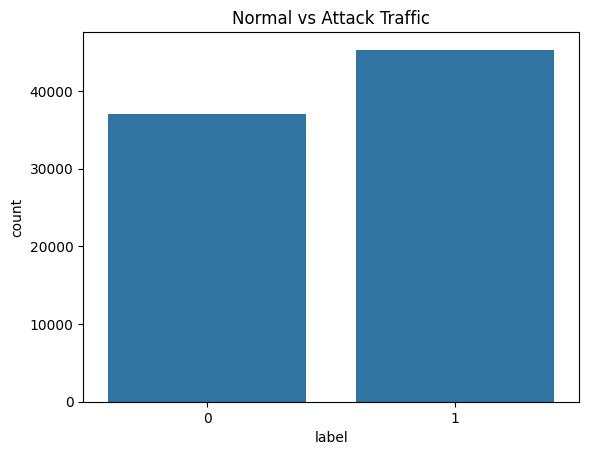

In [9]:
# Visualize normal vs attack traffic

sns.countplot(x='label', data=df)
plt.title("Normal vs Attack Traffic")
plt.show()

In [10]:
# Check categorical columns

df.select_dtypes(include=['object']).columns

Index(['proto', 'service', 'state', 'attack_cat'], dtype='object')

In [11]:
# Encode categorical features

from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df['proto'] = encoder.fit_transform(df['proto'])
df['service'] = encoder.fit_transform(df['service'])
df['state'] = encoder.fit_transform(df['state'])

In [12]:
# Display dataset after encoding

df.head()

,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.000011,117,0,4,2,0,496,0,90909.0902,...,1,2,0,0,0,1,2,0,Normal,0
1,2,0.000008,117,0,4,2,0,1762,0,125000.0003,...,1,2,0,0,0,1,2,0,Normal,0
2,3,0.000005,117,0,4,2,0,1068,0,200000.0051,...,1,3,0,0,0,1,3,0,Normal,0
3,4,0.000006,117,0,4,2,0,900,0,166666.6608,...,1,3,0,0,0,2,3,0,Normal,0
4,5,0.000010,117,0,4,2,0,2126,0,100000.0025,...,1,3,0,0,0,2,3,0,Normal,0


In [14]:
# Drop attack category column

df = df.drop(['attack_cat'], axis=1)

In [13]:
# Check dataset shape after dropping column

df.shape

(82332, 45)

In [15]:
# Define features and target

X = df.drop('label', axis=1)
y = df['label']

In [16]:
# Display target variable

y.head()

,label
0,0
1,0
2,0
3,0
4,0


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [18]:
# Display training and testing sizes

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (57632, 43)
Testing data shape: (24700, 43)


MODEL IMPLEMENTATION

In this section, the Decision Tree algorithm is implemented on the
UNSW-NB15 dataset to detect network anomalies and classify
network traffic as normal or attack.

In [19]:
# Train Decision Tree Model

dt_model = DecisionTreeClassifier()

dt_model.fit(X_train, y_train)

DecisionTreeClassifier()

In [20]:
# Predict on test data

y_pred = dt_model.predict(X_test)

In [21]:
# Calculate model accuracy

accuracy = accuracy_score(y_test, y_pred)

print("Decision Tree Accuracy: {:.2f}%".format(accuracy * 100))

Decision Tree Accuracy: 99.92%


In [22]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[11137    10]
 [   10 13543]]


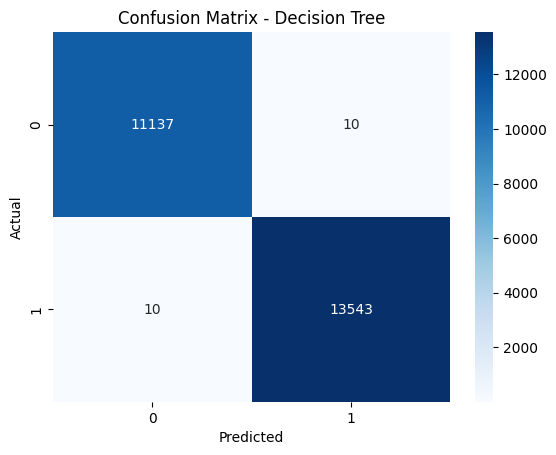

In [23]:
# Plot confusion matrix

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [24]:
# Classification Report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     11147
           1       1.00      1.00      1.00     13553

    accuracy                           1.00     24700
   macro avg       1.00      1.00      1.00     24700
weighted avg       1.00      1.00      1.00     24700



In [25]:
import pickle
with open('decision_tree_model.pkl', 'wb') as f:
    pickle.dump(dt_model, f)

RESULT

The Decision Tree model was successfully implemented on the
UNSW-NB15 dataset for network anomaly detection. The model
was trained and evaluated using the dataset, and it achieved
good classification performance in detecting normal and
malicious network traffic.